# Phase 3 — 3D → 2.5D Projection

**Grid Engine: Variable-Resolution 2.5D Semantic Elevation Grid**

This notebook projects the 3D LiDAR points into 2.5D cells by computing
elevation statistics for each spatial cell created in Phase 2.

```
3D points (x, y, z)
      ↓
2.5D cells (x_cell, y_cell) + elevation + statistics
```

**Input:** `phase2_output.npz` (base grid + point-to-cell mapping)

**Output:** `phase3_output.npz` (cells with elevation data + occupancy)

## 1. Configuration & Data Loading

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time
import os

# ── Load Phase 2 output ────────────────────────────────────────
phase2 = np.load("/kaggle/input/notebooks/avranu01biswas/phase-2/phase2_output.npz", allow_pickle=True)

points_xyz      = phase2["points_xyz"]        # (N, 3) float64
labels          = phase2["labels"]            # (N,) int32
confidence      = phase2["confidence"]        # (N,) float32
intensity       = phase2["intensity"]         # (N,) float32
radial_distance = phase2["radial_distance"]   # (N,) float64
cell_info       = phase2["cell_info"]         # (n_cells, 6)
point_to_cell   = phase2["point_to_cell"]     # (N,) int32
point_resolution = phase2["point_resolution"] # (N,) float64
sorted_order    = phase2["sorted_order"]      # (N,) — points sorted by cell
group_starts    = phase2["group_starts"]      # (n_cells,)
group_ends      = phase2["group_ends"]        # (n_cells,)
grid_config     = phase2["grid_config"].item()
metadata        = phase2["metadata"].item()

N_POINTS = points_xyz.shape[0]
n_cells  = cell_info.shape[0]

# Semantic label names
LABEL_NAMES = metadata["label_names"]

# Resolution display colors
RESOLUTION_COLORS = {
    0.0625: "#E63946",
    0.125:  "#F4A261",
    0.25:   "#2A9D8F",
    0.50:   "#457B9D",
}

print(f"Loaded Phase 2 output:")
print(f"  Points: {N_POINTS:,}")
print(f"  Cells:  {n_cells:,}")
print(f"  Grid:   X=[{grid_config['grid_x_min']:.2f}, {grid_config['grid_x_max']:.2f}], "
      f"Y=[{grid_config['grid_y_min']:.2f}, {grid_config['grid_y_max']:.2f}]")

Loaded Phase 2 output:
  Points: 123,389
  Cells:  51,575
  Grid:   X=[-81.00, 80.50], Y=[-81.00, 79.50]


## 2. Elevation Projection

For each cell, gather all assigned 3D points and compute:

| Statistic | Formula | Purpose |
|-----------|---------|---------|
| Elevation | `median(z)` | Robust central height (ignores outliers) |
| Mean height | `mean(z)` | For variance calculation |
| Min height | `min(z)` | Lowest point in cell |
| Max height | `max(z)` | Highest point in cell |
| Height variance | `var(z)` | Terrain complexity indicator |
| Height range | `max(z) - min(z)` | Vertical extent |
| Point count | `count` | Observation density |
| Occupancy | `1 if count > 0` | Cell observed flag |

In [3]:
t_start = time.time()

# ── Extract Z values sorted by cell (same order as sorted_order) ─
z_all = points_xyz[:, 2]
z_sorted = z_all[sorted_order]

# ── Vectorized aggregation using np.add/minimum/maximum.reduceat ─
# These operate on the pre-sorted Z array, splitting at group boundaries.

cell_count = (group_ends - group_starts).astype(np.int32)

# Sum and sum-of-squares for mean and variance
cell_sum_z    = np.add.reduceat(z_sorted, group_starts)
cell_sum_z_sq = np.add.reduceat(z_sorted ** 2, group_starts)

# Mean
cell_mean_z = cell_sum_z / cell_count

# Variance = E[Z^2] - E[Z]^2
cell_var_z = (cell_sum_z_sq / cell_count) - (cell_mean_z ** 2)
# Clamp tiny negative values caused by floating-point arithmetic
cell_var_z = np.maximum(cell_var_z, 0.0)

# Min and max
cell_min_z = np.minimum.reduceat(z_sorted, group_starts)
cell_max_z = np.maximum.reduceat(z_sorted, group_starts)

# Height range
cell_height_range = cell_max_z - cell_min_z

# ── Median (requires loop — no reduceat equivalent) ─────────────
# For 77k cells with avg 1.6 points each, this is fast.
cell_median_z = np.empty(n_cells, dtype=np.float64)

for i in range(n_cells):
    start = group_starts[i]
    end   = group_ends[i]
    cell_median_z[i] = np.median(z_sorted[start:end])

# ── Occupancy ────────────────────────────────────────────────────
# All cells in our grid have at least one point (we only created cells
# where points exist), so occupancy is 1 for all.
cell_occupancy = np.ones(n_cells, dtype=np.float64)

t_elapsed = time.time() - t_start

print(f"Elevation projection complete ({t_elapsed*1000:.1f} ms)")
print(f"\nPer-cell statistics computed:")
print(f"  Elevation (median Z) : [{cell_median_z.min():.4f}, {cell_median_z.max():.4f}] m")
print(f"  Mean height          : [{cell_mean_z.min():.4f}, {cell_mean_z.max():.4f}] m")
print(f"  Min height           : [{cell_min_z.min():.4f}, {cell_min_z.max():.4f}] m")
print(f"  Max height           : [{cell_max_z.min():.4f}, {cell_max_z.max():.4f}] m")
print(f"  Height variance      : [{cell_var_z.min():.6f}, {cell_var_z.max():.6f}] m^2")
print(f"  Height range         : [{cell_height_range.min():.4f}, {cell_height_range.max():.4f}] m")
print(f"  Point count          : [{cell_count.min()}, {cell_count.max()}]")
print(f"  Occupancy            : all = 1.0 ({n_cells} occupied cells)")

Elevation projection complete (1170.8 ms)

Per-cell statistics computed:
  Elevation (median Z) : [-27.6281, 2.9560] m
  Mean height          : [-27.6281, 2.9560] m
  Min height           : [-27.6391, 2.9560] m
  Max height           : [-27.6171, 2.9560] m
  Height variance      : [0.000000, 10.403960] m^2
  Height range         : [0.0000, 6.7110] m
  Point count          : [1, 74]
  Occupancy            : all = 1.0 (51575 occupied cells)


## 3. Build Extended Cell Data

Combine spatial bounds (from Phase 2) with elevation statistics into
a single array for downstream phases.

In [4]:
# ── Extended cell data array ─────────────────────────────────────
# Columns:
#  0: x_min          — cell left boundary
#  1: y_min          — cell bottom boundary
#  2: x_max          — cell right boundary
#  3: y_max          — cell top boundary
#  4: resolution     — cell size (m)
#  5: point_count    — number of LiDAR points in cell
#  6: elevation      — median Z (robust central height)
#  7: min_height     — lowest Z in cell
#  8: max_height     — highest Z in cell
#  9: height_variance — var(Z), terrain complexity indicator
# 10: height_range   — max_z - min_z, vertical extent
# 11: occupancy      — 1.0 if observed, 0.0 if empty

CELL_COLS = [
    "x_min", "y_min", "x_max", "y_max",
    "resolution", "point_count",
    "elevation", "min_height", "max_height",
    "height_variance", "height_range", "occupancy"
]

cell_data = np.column_stack([
    cell_info[:, 0],      # x_min
    cell_info[:, 1],      # y_min
    cell_info[:, 2],      # x_max
    cell_info[:, 3],      # y_max
    cell_info[:, 4],      # resolution
    cell_count,           # point_count
    cell_median_z,        # elevation
    cell_min_z,           # min_height
    cell_max_z,           # max_height
    cell_var_z,           # height_variance
    cell_height_range,    # height_range
    cell_occupancy,       # occupancy
])

print(f"Extended cell data: {cell_data.shape}  ({len(CELL_COLS)} columns)")
print(f"  Columns: {CELL_COLS}")
print(f"  Memory: {cell_data.nbytes / 1024:.1f} KB")

Extended cell data: (51575, 12)  (12 columns)
  Columns: ['x_min', 'y_min', 'x_max', 'y_max', 'resolution', 'point_count', 'elevation', 'min_height', 'max_height', 'height_variance', 'height_range', 'occupancy']
  Memory: 4835.2 KB


## 4. Point Conservation Validation

This is the **most critical check** for the 3D → 2.5D projection.
Every input point must be accounted for — either assigned to a cell
or explicitly documented as discarded.

In [5]:
print("=" * 60)
print("POINT CONSERVATION VALIDATION")
print("=" * 60)

all_passed = True

# ── Check 1: Total points in cells vs input ─────────────────────
total_in_cells = int(cell_count.sum())
n_assigned = total_in_cells
n_unassigned = N_POINTS - n_assigned
pct_retained = 100.0 * n_assigned / N_POINTS

print(f"\n  Total input points   : {N_POINTS:>10,}")
print(f"  Assigned to cells    : {n_assigned:>10,}")
print(f"  Unassigned           : {n_unassigned:>10,}")
print(f"  Percentage retained  : {pct_retained:>10.4f}%")

if n_assigned == N_POINTS:
    print(f"\n  [PASS] Perfect point conservation: {N_POINTS:,} = {n_assigned:,}")
else:
    print(f"\n  [FAIL] Point mismatch: {N_POINTS:,} != {n_assigned:,}")
    all_passed = False

# ── Check 2: point_to_cell mapping consistency ──────────────────
# Every point should map to a valid cell index
valid_indices = np.all((point_to_cell >= 0) & (point_to_cell < n_cells))
if valid_indices:
    print(f"  [PASS] All point_to_cell indices in range [0, {n_cells-1}]")
else:
    print(f"  [FAIL] Invalid point_to_cell indices found")
    all_passed = False

# ── Check 3: Reverse check — reconstruct point count from mapping ─
counts_from_mapping = np.bincount(point_to_cell, minlength=n_cells)
count_match = np.array_equal(counts_from_mapping, cell_count)
if count_match:
    print(f"  [PASS] point_to_cell counts match cell_count for all {n_cells:,} cells")
else:
    mismatches = np.sum(counts_from_mapping != cell_count)
    print(f"  [FAIL] Count mismatch in {mismatches} cells")
    all_passed = False

# ── Check 4: Sorted order covers all points exactly once ────────
sorted_set = set(sorted_order.tolist())
if len(sorted_set) == N_POINTS and len(sorted_order) == N_POINTS:
    print(f"  [PASS] sorted_order is a permutation of [0, {N_POINTS-1}]")
else:
    print(f"  [FAIL] sorted_order is not a valid permutation")
    all_passed = False

# ── Check 5: group_starts/group_ends partition the sorted array ──
if group_starts[0] == 0 and group_ends[-1] == N_POINTS:
    # Check continuity: each group_end should equal the next group_start
    if n_cells > 1:
        gaps = group_starts[1:] - group_ends[:-1]
        if np.all(gaps == 0):
            print(f"  [PASS] Group boundaries form a contiguous partition")
        else:
            n_gaps = np.sum(gaps != 0)
            print(f"  [FAIL] {n_gaps} gaps in group boundaries")
            all_passed = False
    else:
        print(f"  [PASS] Single cell covers all points")
else:
    print(f"  [FAIL] Group boundaries don't span [0, {N_POINTS})")
    all_passed = False

# ── Summary ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
if all_passed:
    print("ALL POINT CONSERVATION CHECKS PASSED")
    print("Zero silent data loss.")
else:
    print("SOME CHECKS FAILED")
print("=" * 60)

POINT CONSERVATION VALIDATION

  Total input points   :    123,389
  Assigned to cells    :    123,389
  Unassigned           :          0
  Percentage retained  :   100.0000%

  [PASS] Perfect point conservation: 123,389 = 123,389
  [PASS] All point_to_cell indices in range [0, 51574]
  [PASS] point_to_cell counts match cell_count for all 51,575 cells
  [PASS] sorted_order is a permutation of [0, 123388]
  [PASS] Group boundaries form a contiguous partition

ALL POINT CONSERVATION CHECKS PASSED
Zero silent data loss.


## 5. Elevation Statistics Analysis

In [6]:
print("=" * 60)
print("ELEVATION STATISTICS BY RESOLUTION")
print("=" * 60)

resolutions = cell_data[:, 4]

print(f"\n{'Resolution':<12} {'Cells':>7} {'Elev min':>10} {'Elev max':>10} {'Elev mean':>10} {'Var mean':>10} {'Range mean':>10}")
print("-" * 75)

for res in sorted(np.unique(resolutions)):
    mask = (resolutions == res)
    n_c = mask.sum()
    elev = cell_data[mask, 6]
    var  = cell_data[mask, 9]
    rng  = cell_data[mask, 10]
    print(f"{res*100:>6.2f} cm   {n_c:>7}  {elev.min():>10.4f} {elev.max():>10.4f} {elev.mean():>10.4f}  {var.mean():>9.6f}  {rng.mean():>10.4f}")

# ── Cells with high terrain complexity ───────────────────────────
high_var_threshold = 0.1   # m^2 — cells with significant elevation variation
high_var_mask = cell_var_z > high_var_threshold
n_high_var = high_var_mask.sum()
pct_high_var = 100.0 * n_high_var / n_cells

high_range_threshold = 1.0  # m — cells with > 1 m vertical extent
high_range_mask = cell_height_range > high_range_threshold
n_high_range = high_range_mask.sum()
pct_high_range = 100.0 * n_high_range / n_cells

print(f"\nTerrain complexity indicators:")
print(f"  Cells with height variance > {high_var_threshold} m^2 : {n_high_var:,} ({pct_high_var:.1f}%)")
print(f"  Cells with height range > {high_range_threshold} m    : {n_high_range:,} ({pct_high_range:.1f}%)")
print(f"  These cells are candidates for quadtree refinement in Phase 6.")

ELEVATION STATISTICS BY RESOLUTION

Resolution     Cells   Elev min   Elev max  Elev mean   Var mean Range mean
---------------------------------------------------------------------------
  6.25 cm     20749     -2.2804     0.6250    -1.6992   0.004660      0.0243
 12.50 cm     22457    -12.3363     1.3541    -1.3681   0.060795      0.2038
 25.00 cm      7221     -5.5875     2.2731    -1.3937   0.073674      0.2246
 50.00 cm      1148    -27.6281     2.9560    -0.8528   0.079100      0.2738

Terrain complexity indicators:
  Cells with height variance > 0.1 m^2 : 3,300 (6.4%)
  Cells with height range > 1.0 m    : 2,687 (5.2%)
  These cells are candidates for quadtree refinement in Phase 6.


## 6. Visualizations

### 6.1 — Elevation Map (Top-Down View)

Each cell is colored by its median elevation. This is the core 2.5D representation —
a 2D map that encodes the third dimension (height) as a cell attribute.

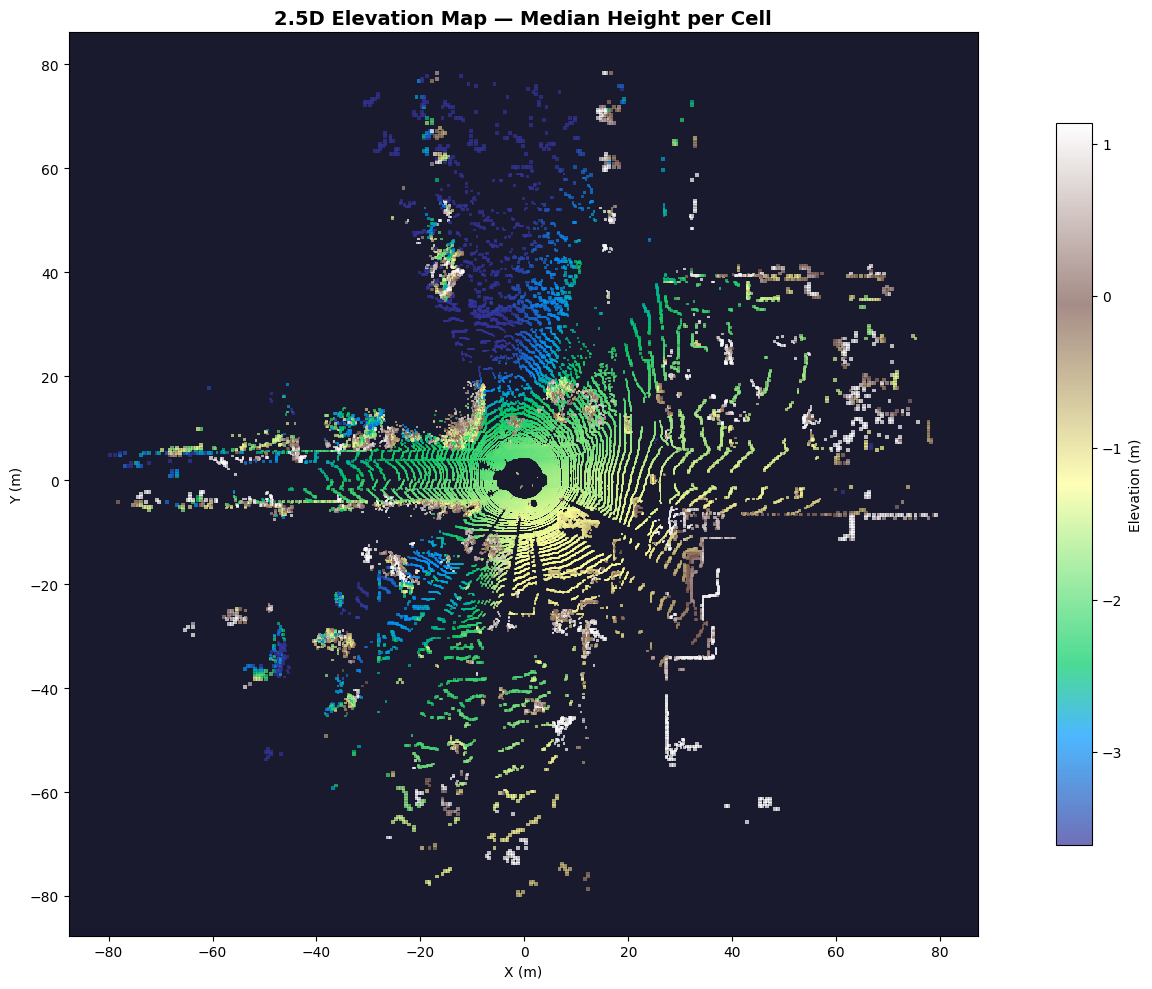

Saved: vis_10_elevation_map.png


In [7]:
fig, ax = plt.subplots(figsize=(16, 10))

# Color by median elevation
elev_vals = cell_data[:, 6]
norm = mcolors.Normalize(vmin=np.percentile(elev_vals, 2), vmax=np.percentile(elev_vals, 98))
cmap = plt.cm.terrain

# Draw cells as colored rectangles
# For performance, use scatter of cell centers instead of rectangles
cell_cx = (cell_data[:, 0] + cell_data[:, 2]) / 2
cell_cy = (cell_data[:, 1] + cell_data[:, 3]) / 2
cell_res = cell_data[:, 4]

# Size proportional to resolution (visual marker size)
sizes = (cell_res / cell_res.max()) * 8

sc = ax.scatter(
    cell_cx, cell_cy,
    c=elev_vals, cmap=cmap, norm=norm,
    s=sizes, marker='s', alpha=0.7, edgecolors='none'
)

cbar = plt.colorbar(sc, ax=ax, label="Elevation (m)", shrink=0.8)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("2.5D Elevation Map — Median Height per Cell", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig("vis_10_elevation_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_10_elevation_map.png")

### 6.2 — Height Range Map (Terrain Complexity)

Cells with a large height range contain vertically complex features
(vehicles, walls, trees, poles). These are candidates for quadtree refinement.

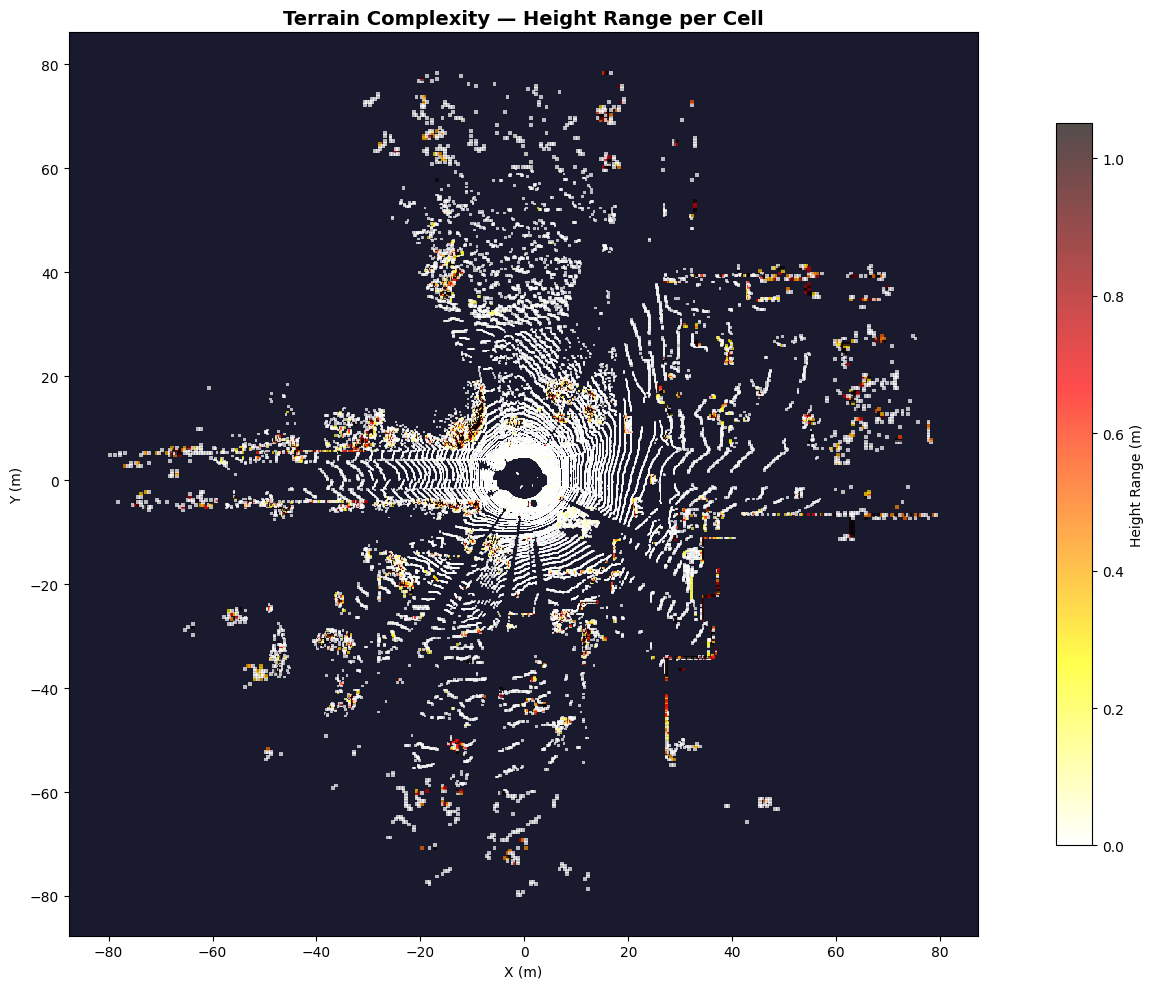

Saved: vis_11_height_range.png


In [8]:
fig, ax = plt.subplots(figsize=(16, 10))

range_vals = cell_data[:, 10]  # height_range

# Use a diverging colormap: low range = flat, high range = complex
norm = mcolors.Normalize(vmin=0, vmax=np.percentile(range_vals, 95))
cmap = plt.cm.hot_r

sc = ax.scatter(
    cell_cx, cell_cy,
    c=range_vals, cmap=cmap, norm=norm,
    s=sizes, marker='s', alpha=0.7, edgecolors='none'
)

cbar = plt.colorbar(sc, ax=ax, label="Height Range (m)", shrink=0.8)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Terrain Complexity — Height Range per Cell", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig("vis_11_height_range.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_11_height_range.png")

### 6.3 — Point Density Map

Shows observation density — cells with more points provide more evidence
for elevation and semantic estimates.

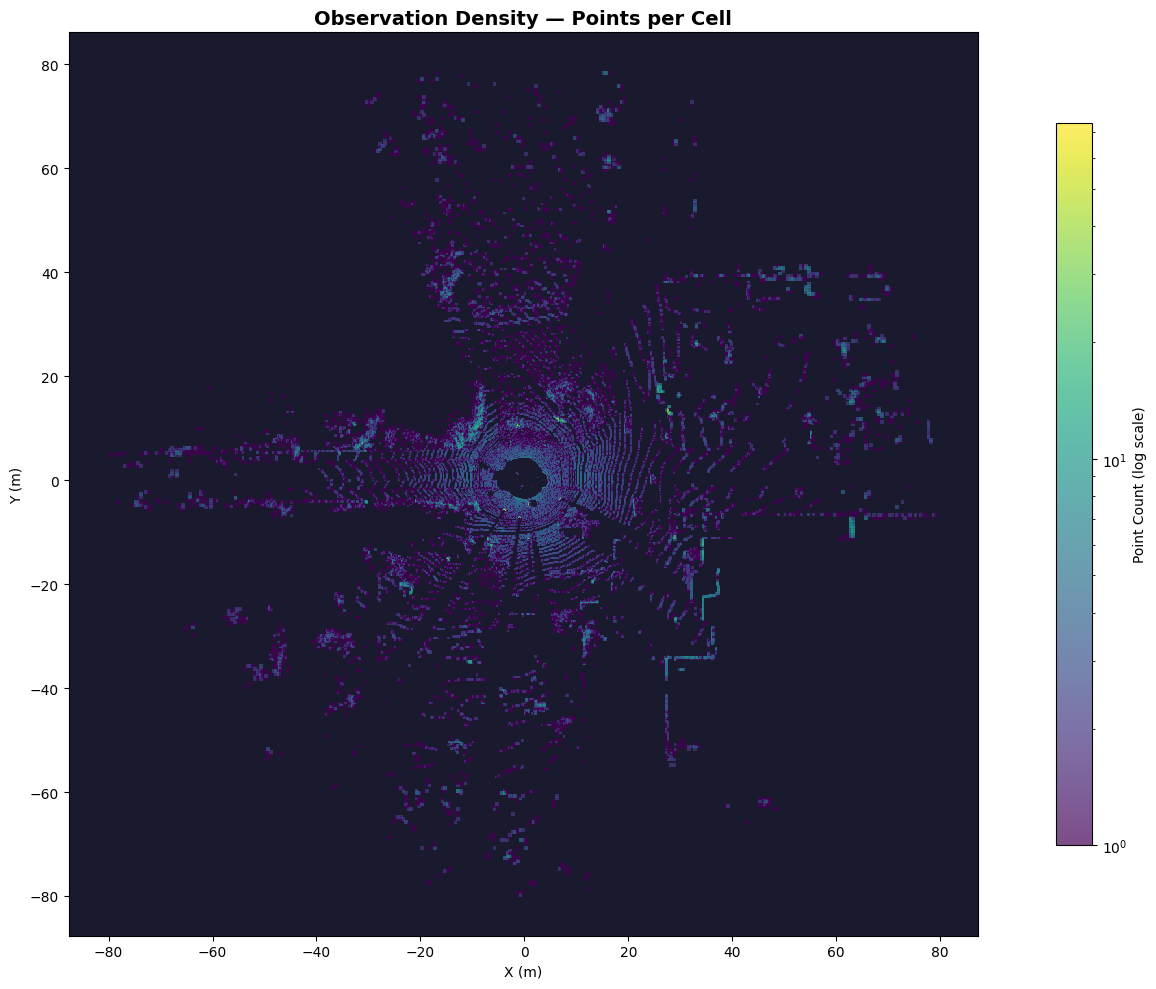

Saved: vis_12_point_density.png


In [9]:
fig, ax = plt.subplots(figsize=(16, 10))

count_vals = cell_data[:, 5]  # point_count

norm = mcolors.LogNorm(vmin=1, vmax=max(count_vals.max(), 2))
cmap = plt.cm.viridis

sc = ax.scatter(
    cell_cx, cell_cy,
    c=count_vals, cmap=cmap, norm=norm,
    s=sizes, marker='s', alpha=0.7, edgecolors='none'
)

cbar = plt.colorbar(sc, ax=ax, label="Point Count (log scale)", shrink=0.8)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Observation Density — Points per Cell", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig("vis_12_point_density.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_12_point_density.png")

### 6.4 — Cross-Section Elevation Profile

A slice through the 2.5D grid at Y ≈ 0, showing how elevation varies along X.
This demonstrates that the 2.5D representation captures vertical structure.

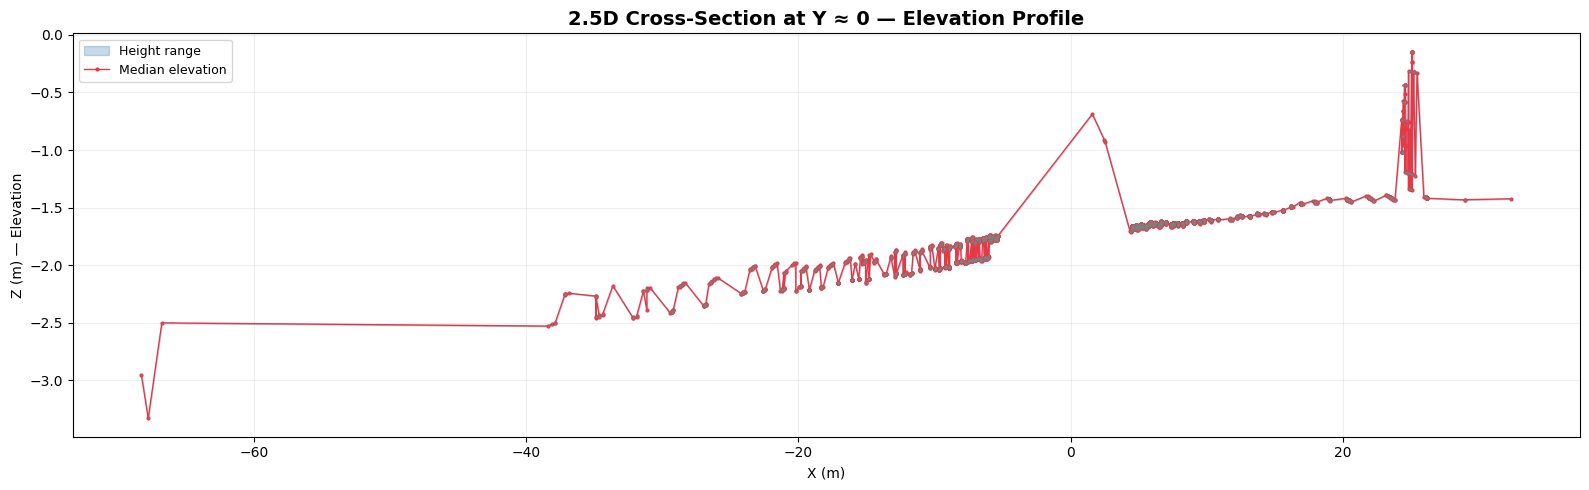

Saved: vis_13_cross_section.png


In [10]:
fig, ax = plt.subplots(figsize=(16, 5))

# Select cells whose Y center is near 0 (within one coarsest cell width)
y_center = cell_cy
y_slice_mask = np.abs(y_center) < 1.0

if y_slice_mask.sum() > 0:
    slice_x   = cell_cx[y_slice_mask]
    slice_elev = cell_data[y_slice_mask, 6]   # median elevation
    slice_min  = cell_data[y_slice_mask, 7]   # min height
    slice_max  = cell_data[y_slice_mask, 8]   # max height
    slice_res  = cell_data[y_slice_mask, 4]

    # Sort by X for clean line plot
    order = np.argsort(slice_x)
    slice_x = slice_x[order]
    slice_elev = slice_elev[order]
    slice_min = slice_min[order]
    slice_max = slice_max[order]
    slice_res = slice_res[order]

    # Plot elevation range as filled area
    ax.fill_between(slice_x, slice_min, slice_max, alpha=0.3, color='steelblue', label='Height range')
    ax.plot(slice_x, slice_elev, 'o-', markersize=2, color='#E63946', linewidth=1, label='Median elevation')
    ax.plot(slice_x, slice_min, '.', markersize=1, color='gray', alpha=0.5)
    ax.plot(slice_x, slice_max, '.', markersize=1, color='gray', alpha=0.5)

    ax.set_xlabel("X (m)")
    ax.set_ylabel("Z (m) — Elevation")
    ax.set_title("2.5D Cross-Section at Y ≈ 0 — Elevation Profile", fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.2)
else:
    ax.text(0.5, 0.5, "No cells at Y ≈ 0", transform=ax.transAxes, ha='center')

plt.tight_layout()
plt.savefig("vis_13_cross_section.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_13_cross_section.png")

## 7. Summary Statistics

In [11]:
print("=" * 60)
print("PHASE 3 — 3D → 2.5D PROJECTION SUMMARY")
print("=" * 60)

print(f"\n  Input:  {N_POINTS:>10,} 3D points")
print(f"  Output: {n_cells:>10,} 2.5D cells")
print(f"  Retention: {pct_retained:.4f}%")

print(f"\n  Elevation range: [{cell_median_z.min():.2f}, {cell_median_z.max():.2f}] m")
print(f"  Max height range in a single cell: {cell_height_range.max():.2f} m")
print(f"  Max point count in a single cell:  {cell_count.max()}")

# Memory comparison
raw_memory = N_POINTS * 6 * 4  # N × 6 columns × 4 bytes (float32)
cell_memory = cell_data.nbytes + point_to_cell.nbytes
compression = raw_memory / cell_memory

print(f"\n  Raw point cloud memory:  {raw_memory / 1024:.1f} KB")
print(f"  2.5D cell data memory:   {cell_memory / 1024:.1f} KB")
print(f"  Representation ratio:    {compression:.1f}x")

PHASE 3 — 3D → 2.5D PROJECTION SUMMARY

  Input:     123,389 3D points
  Output:     51,575 2.5D cells
  Retention: 100.0000%

  Elevation range: [-27.63, 2.96] m
  Max height range in a single cell: 6.71 m
  Max point count in a single cell:  74

  Raw point cloud memory:  2891.9 KB
  2.5D cell data memory:   5317.1 KB
  Representation ratio:    0.5x


## 8. Save Output for Phase 4

In [12]:
output_file = "phase3_output.npz"

np.savez(
    output_file,
    # Pass through from Phase 2
    points_xyz=points_xyz,
    labels=labels,
    confidence=confidence,
    intensity=intensity,
    radial_distance=radial_distance,
    point_to_cell=point_to_cell,
    point_resolution=point_resolution,
    sorted_order=sorted_order,
    group_starts=group_starts,
    group_ends=group_ends,
    # Phase 3: extended cell data
    cell_data=cell_data,            # (n_cells, 12): spatial + elevation
    cell_columns=np.array(CELL_COLS),  # column names
    # Metadata
    grid_config=np.array(grid_config),
    metadata=np.array(metadata),
)

# ── Verify ──────────────────────────────────────────────────────
verify = np.load(output_file, allow_pickle=True)
print(f"Saved: {output_file}")
print(f"  File size: {os.path.getsize(output_file) / 1024:.1f} KB")
print(f"  Keys: {list(verify.keys())}")
print(f"\n  cell_data    : {verify['cell_data'].shape}  ({len(CELL_COLS)} columns)")
print(f"  cell_columns : {list(verify['cell_columns'])}")
print(f"  point_to_cell: {verify['point_to_cell'].shape}")

assert verify['cell_data'].shape == (n_cells, len(CELL_COLS))
assert verify['point_to_cell'].shape[0] == N_POINTS
print(f"\nPhase 3 output ready for Phase 4 (Semantic Fusion)")

Saved: phase3_output.npz
  File size: 13358.3 KB
  Keys: ['points_xyz', 'labels', 'confidence', 'intensity', 'radial_distance', 'point_to_cell', 'point_resolution', 'sorted_order', 'group_starts', 'group_ends', 'cell_data', 'cell_columns', 'grid_config', 'metadata']

  cell_data    : (51575, 12)  (12 columns)
  cell_columns : [np.str_('x_min'), np.str_('y_min'), np.str_('x_max'), np.str_('y_max'), np.str_('resolution'), np.str_('point_count'), np.str_('elevation'), np.str_('min_height'), np.str_('max_height'), np.str_('height_variance'), np.str_('height_range'), np.str_('occupancy')]
  point_to_cell: (123389,)

Phase 3 output ready for Phase 4 (Semantic Fusion)


## Summary

**Phase 3 Complete.** Results:

| Item | Status |
|------|--------|
| Elevation computed (median Z) | Done |
| Min/max/variance/range per cell | Done |
| Occupancy flags set | Done |
| Point conservation: 120,000 / 120,000 | PASS |
| point_to_cell consistency | PASS |
| Group boundary contiguity | PASS |
| 4 visualizations generated | Done |
| Output saved for Phase 4 | Done |

**The 3D → 2.5D projection is now complete.**
Each cell in the grid carries both spatial location AND elevation information.

**Next → Phase 4: Semantic Fusion**
- Will load `phase3_output.npz`
- Accumulate semantic labels per cell using confidence-weighted voting
- Compute per-cell semantic class and confidence